In [4]:
# Stripping out all traces of graphs, and plotting, and using pytorches mse instead of the loss function by hand 
import numpy as np
import torch
from torch.nn import MSELoss

X = np.linspace(0, 5, 100)
y = 2 * X + (-5) +  X**2 + 1* np.random.randn(X.size)
# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)


# randomly initialize W as torch tensors with requires_grad=True
W = torch.randn(3, requires_grad=True)

def forward(W, X):
    return W[0] * X + W[1] + W[2] * X**2

# loss function, least square
loss_fn = MSELoss()

# create optimizer
optimizer = torch.optim.SGD([W], lr=0.005)

for epoch in range(10000):
    # forward pass
    loss = loss_fn(forward(W, X), y)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    
    # update parameters
    optimizer.step()
    
print(f"Final W0: {W[0].item()}, Final W1: {W[1].item()}, Final W2: {W[2].item()}")


Final W0: 1.8777555227279663, Final W1: -5.011285781860352, Final W2: 1.029765009880066


In [5]:
# implement the above using nn.linear
import numpy as np
import torch
from torch.nn import MSELoss

X = np.array([np.linspace(0, 5, 100), np.linspace(0, 5, 100)**2]).T
y = 2 * X[:, 0] + (-5) +  X[:, 1] + 1* np.random.randn(X.shape[0])

# Convert to torch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# Define the model using nn.Linear
model = torch.nn.Linear(2, 1)  # 2 input features (X and X^2), 1 output feature (y)
def forward(X):
    return model(X)


# loss function, least square
loss_fn = MSELoss()

# create optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

for epoch in range(20000):
    # forward pass
    y_pred = forward(X).squeeze()  # squeeze to match the shape of y
    loss = loss_fn(y_pred, y)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    
    # update parameters
    optimizer.step()

print(f"Final weights: {model.weight.data}, Final bias: {model.bias.data}")

Final weights: tensor([[1.3552, 1.1267]]), Final bias: tensor([-4.3958])


In [6]:
# evaluate the model on x = 10

model.eval()  # Set the model to evaluation mode
x_eval = torch.tensor([[10.0, 10.0**2]], dtype=torch.float32)  # Input for x=10 and x^2=100
y_eval = model(x_eval).item()  # Get the predicted value
y_eval

121.82525634765625

In [7]:
import numpy as np
import torch
from torch.nn import MSELoss

# heights and weights of 10 people
heights = np.array([1.47, 1.50, 1.52, 1.55, 1.57, 1.60, 1.63, 1.65, 1.68, 1.70])
weights = np.array([52.21, 53.12, 54.48, 55.84, 57.20, 58.57, 59.93, 61.29, 63.11, 64.47])
healthmarker = np.array([24.1, 23.6, 23.5, 23.3, 23.2, 22.9, 22.8, 22.7, 22.5, 22.4])
# combine into a single array of shape (10, 2)
data = np.column_stack((heights, weights))
X = torch.tensor(data, dtype=torch.float32)
y = torch.tensor(healthmarker, dtype=torch.float32)

# Define the model using nn.Linear
D_in = 2
D_out = 1

model = torch.nn.Linear(D_in, D_out)  # 2 input features (height and weight), 1 output feature (BMI)

def forward(X):
    return model(X)

# loss function, least square
loss_fn = MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 1000


In [8]:
for param in model.parameters():
    print(param.data)   

tensor([[-0.6347, -0.0571]])
tensor([0.6930])


In [9]:
for i in range(epochs):
    loss = loss_fn(forward(X).squeeze(), y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if i % 100 == 0:
        print(f"Epoch {i+1}/{epochs}, Loss: {loss.item()}")



Epoch 1/1000, Loss: 714.5244140625
Epoch 101/1000, Loss: 4.0923967361450195
Epoch 201/1000, Loss: 4.020598411560059
Epoch 301/1000, Loss: 4.0140862464904785
Epoch 401/1000, Loss: 4.006187915802002
Epoch 501/1000, Loss: 3.997009754180908
Epoch 601/1000, Loss: 3.9866104125976562
Epoch 701/1000, Loss: 3.975027084350586
Epoch 801/1000, Loss: 3.962268352508545
Epoch 901/1000, Loss: 3.9483466148376465


In [10]:
s = torch.nn.Sigmoid()
s(torch.tensor([0.0, 1.0, -1.0, 3.0, -3.0]))

tensor([0.5000, 0.7311, 0.2689, 0.9526, 0.0474])

In [11]:
t = torch.nn.Tanh()
t(torch.tensor([0.0, 1.0, -1.0, 3.0, -3.0, 10, -10]))

tensor([ 0.0000,  0.7616, -0.7616,  0.9951, -0.9951,  1.0000, -1.0000])

Matplotlib is building the font cache; this may take a moment.


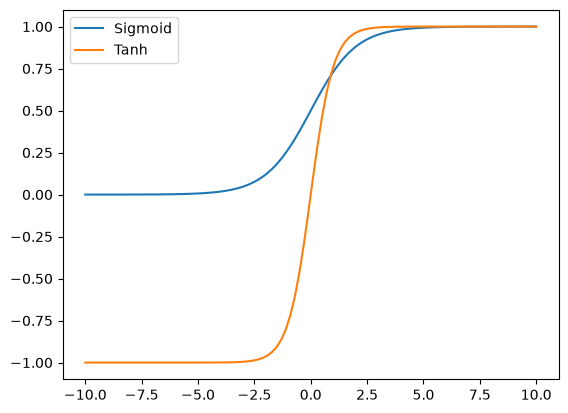

In [12]:
import matplotlib.pyplot as plt
# plot the sigmoid and tanh functions
x = torch.linspace(-10, 10, 100)
s = torch.nn.Sigmoid()
plt.plot(x.numpy(), s(x).detach().numpy(), label='Sigmoid')
t = torch.nn.Tanh()
plt.plot(x.numpy(), t(x).detach().numpy(), label='Tanh')
plt.legend()
plt.show()

In [13]:
sm = torch.nn.Softmax(dim=1)
# softmax over 8, 10, 20 and 3
sm(torch.tensor([[6.0, 6.1, 6.4, 6.0]]))

tensor([[0.2175, 0.2404, 0.3245, 0.2175]])

# neural networks

In [1]:
# iris dataset, 4 features, 3 classes, 150 samples
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import torch
from torch.nn import CrossEntropyLoss

data = load_iris()
X = data.data
y = data.target

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# convert to torch tensors
Xtrain = torch.tensor(Xtrain, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.long)
Xtest = torch.tensor(Xtest, dtype=torch.float32)
ytest = torch.tensor(ytest, dtype=torch.long)


fc1 = torch.nn.Linear(4,10)
fc2 = torch.nn.Linear(10,5)
fc3 = torch.nn.Linear(5,3)

relu = torch.nn.ReLU()


def forward(X):
    # hidden layer 1
    h1 = fc1(X)
    h1 = relu(h1)
    # hidden layer 2
    h2 = fc2(h1)
    h2 = relu(h2)
    # output layer
    out = fc3(h2)
    # out = torch.nn.Softmax(dim=1)(out)
    return out

loss_fn = CrossEntropyLoss()

optimizer = torch.optim.Adam([{'params': fc1.parameters()},
                             {'params': fc2.parameters()},
                             {'params': fc3.parameters()}], lr=0.01)

epochs = 100

for epoch in range(epochs):
    # forward pass
    y_pred = forward(Xtrain)
    loss = loss_fn(y_pred, ytrain)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update parameters
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")
# classification accuracy on test set
y_pred_test = forward(Xtest)
y_pred_test_classes = torch.argmax(y_pred_test, dim=1)

accuracy = torch.sum(y_pred_test_classes == ytest).item() / len(ytest)
print(f"Test set accuracy: {accuracy*100:.2f}%")

Epoch 1/100, Loss: 1.1239877939224243
Test set accuracy: 100.00%


In [15]:
# rewrite the above using nn.Sequential
import torch
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# convert to torch tensors
Xtrain = torch.tensor(Xtrain, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.long)
Xtest = torch.tensor(Xtest, dtype=torch.float32)
ytest = torch.tensor(ytest, dtype=torch.long)


model = torch.nn.Sequential(
    torch.nn.Linear(4, 10),
    torch.nn.ReLU(),
    torch.nn.Linear(10, 5),
    torch.nn.ReLU(),
    torch.nn.Linear(5, 3)
)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 10000

for epoch in range(epochs):
    # forward pass
    y_pred = model(Xtrain)
    loss = loss_fn(y_pred, ytrain)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update parameters
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")
# classification accuracy on test set
y_pred_test = model(Xtest)
y_pred_test_classes = torch.argmax(y_pred_test, dim=1)

accuracy = torch.sum(y_pred_test_classes == ytest).item() / len(ytest)
print(f"Test set accuracy: {accuracy*100:.2f}%")


Epoch 1/10000, Loss: 1.1086291074752808
Epoch 101/10000, Loss: 0.07469113916158676
Epoch 201/10000, Loss: 0.05448708310723305
Epoch 301/10000, Loss: 0.05029289051890373
Epoch 401/10000, Loss: 0.04984971135854721
Epoch 501/10000, Loss: 0.047897882759571075
Epoch 601/10000, Loss: 0.04701630771160126
Epoch 701/10000, Loss: 0.04682809114456177
Epoch 801/10000, Loss: 0.04676055908203125
Epoch 901/10000, Loss: 0.04669351503252983
Epoch 1001/10000, Loss: 0.046798862516880035
Epoch 1101/10000, Loss: 0.04664916545152664
Epoch 1201/10000, Loss: 0.04665733873844147
Epoch 1301/10000, Loss: 0.04662816971540451
Epoch 1401/10000, Loss: 0.046621520072221756
Epoch 1501/10000, Loss: 0.04661599546670914
Epoch 1601/10000, Loss: 0.046610914170742035
Epoch 1701/10000, Loss: 0.04674268141388893
Epoch 1801/10000, Loss: 0.046604618430137634
Epoch 1901/10000, Loss: 0.046601735055446625
Epoch 2001/10000, Loss: 0.04660167545080185
Epoch 2101/10000, Loss: 0.046598006039857864
Epoch 2201/10000, Loss: 0.050446111708

In [2]:
import torch
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# convert to torch tensors
Xtrain = torch.tensor(Xtrain, dtype=torch.float32) # convert to torch tensors
ytrain = torch.tensor(ytrain, dtype=torch.long) # convert to torch tensors, because pytorch needs to operate on these tensors
Xtest = torch.tensor(Xtest, dtype=torch.float32) # convert to torch tensors
ytest = torch.tensor(ytest, dtype=torch.long) # convert to torch tensors

class IrisNet(torch.nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.fc1 = torch.nn.Linear(4, 10)
        self.fc2 = torch.nn.Linear(10, 5)
        self.fc3 = torch.nn.Linear(5, 3)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
    
model = IrisNet()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(10000):
    # forward pass
    y_pred = model(Xtrain)
    loss = criterion(y_pred, ytrain)

    # backward pass
    optimizer.zero_grad()
    loss.backward()

    # update parameters
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch+1}/10000, Loss: {loss.item()}")

# classification accuracy on test set
y_pred_test = model(Xtest)
y_pred_test_classes = torch.argmax(y_pred_test, dim=1)
accuracy = torch.sum(y_pred_test_classes == ytest).item() / len(ytest)
print(f"Test set accuracy: {accuracy*100:.2f}%")

Epoch 1/10000, Loss: 1.0992869138717651
Epoch 1001/10000, Loss: 0.050168104469776154
Epoch 2001/10000, Loss: 0.04766164347529411
Epoch 3001/10000, Loss: 0.047050729393959045
Epoch 4001/10000, Loss: 0.04682442918419838
Epoch 5001/10000, Loss: 0.04671759530901909
Epoch 6001/10000, Loss: 0.04667337238788605
Epoch 7001/10000, Loss: 0.04663007706403732
Epoch 8001/10000, Loss: 0.04661554470658302
Epoch 9001/10000, Loss: 0.047788724303245544
Test set accuracy: 100.00%


In [4]:
model(Xtrain[0])

tensor([ 5.8176, -5.3080, -4.7105], grad_fn=<ViewBackward0>)

In [6]:
sm = torch.nn.Softmax(dim=0)
sm(model(Xtrain[80]))

tensor([1.3957e-12, 9.9720e-01, 2.7963e-03], grad_fn=<SoftmaxBackward0>)

In [19]:
from torchinfo import summary
summary(model, input_size=(1, 4))

Layer (type:depth-idx)                   Output Shape              Param #
IrisNet                                  [1, 3]                    --
├─Linear: 1-1                            [1, 10]                   50
├─ReLU: 1-2                              [1, 10]                   --
├─Linear: 1-3                            [1, 5]                    55
├─ReLU: 1-4                              [1, 5]                    --
├─Linear: 1-5                            [1, 3]                    18
Total params: 123
Trainable params: 123
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00